In [50]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

Загрузка + очистка данных

In [51]:
df = pd.read_csv('tmdb_5000_movies.csv', usecols=['original_title', 'overview'])
df = df.dropna(subset=['overview']).reset_index(drop=True)
print(f"Количество фильмов после очистки: {df.shape[0]}")

Количество фильмов после очистки: 4800


In [52]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/zeto/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/zeto/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/zeto/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/zeto/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Предобработка:
- очистка текста (нижний регистр, удаление пунктуации и спец символов)
- удалил стоп слова
- лемматизация

In [53]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [54]:
df['processed_overview'] = df['overview'].apply(preprocess_text)

print("Пример предобработанного описания:")
print(df['processed_overview'].iloc[0])

Пример предобработанного описания:
nd century paraplegic marine dispatched moon pandora unique mission becomes torn following order protecting alien civilization


Используем TF-IDF для того, чтобы выделить слова, которые часто появляются в конкретном документе, но редко встречаются в других документах корпуса.

Нужно для того, чтобы выделить ключевые слова, характеризующие содержание документа.

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['processed_overview'])
print(f"Размерность TF-IDF матрицы: {tfidf_matrix.shape}")

Размерность TF-IDF матрицы: (4800, 20461)


- Нормализуем
- Применяем t-SNE (для того, чтобы показать близость объектов в многомерном пространстве в виде точек. Точки рядом - похожие по смыслу фильмы)

In [56]:
scaler = StandardScaler()
tfidf_matrix_scaled = scaler.fit_transform(tfidf_matrix.toarray())

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate=200)
tsne_results = tsne.fit_transform(tfidf_matrix_scaled)

/Users/zeto/Projects/university/7sem/oatea/p4/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


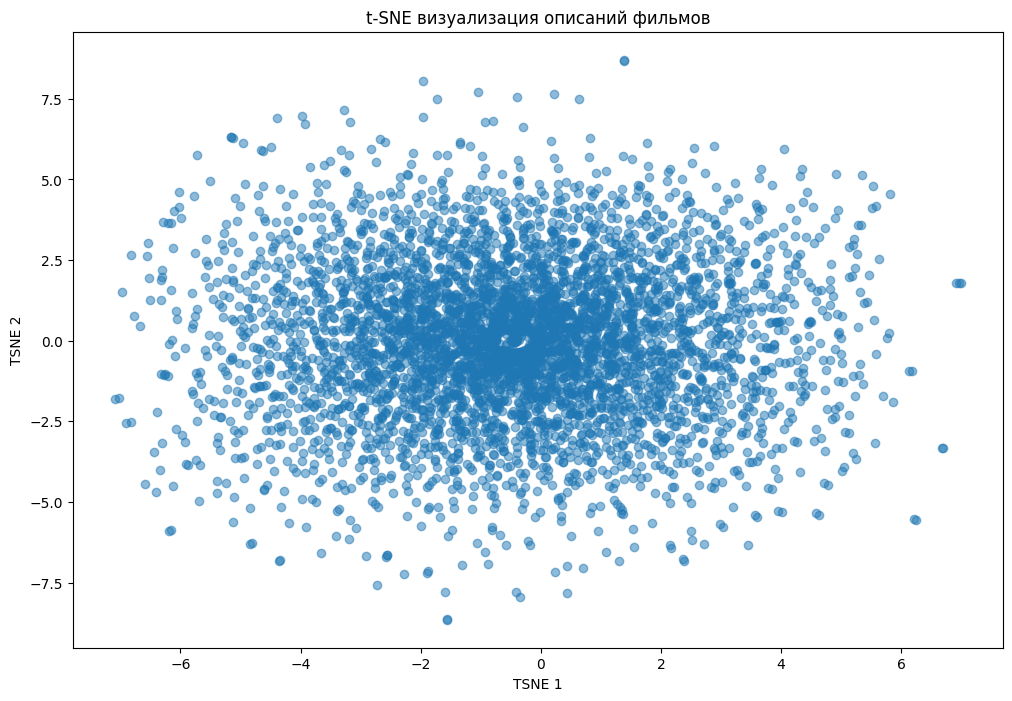

In [57]:
df['tsne_x'] = tsne_results[:, 0]
df['tsne_y'] = tsne_results[:, 1]

plt.figure(figsize=(12, 8))
plt.scatter(df['tsne_x'], df['tsne_y'], alpha=0.5)
plt.title('t-SNE визуализация описаний фильмов')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.show()

- Получение ? для данного фильма
- Сортировка по убыванию сходства
- Выбор top_n+1 фильмов (поскольку первый — сам фильм)

1. Косинусное сходство — измеряет угол между векторами, чем ближе к 1, тем больше сходство.
2. Евклидово расстояние — чем меньше расстояние, тем больше сходство.
3. Манхэттенское расстояние — сумма абсолютных разностей координат, аналогично евклидову расстоянию, но без возведения в квадрат.
4. Жаккардово расстояние — отношение различий к объединению признаков. Для этого матрица TF-IDF бинаризуется, чтобы получить наличие или отсутствие термина.

In [58]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances
from scipy.spatial.distance import jaccard
import numpy as np

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
euclidean_dist = euclidean_distances(tfidf_matrix, tfidf_matrix)
manhattan_dist = manhattan_distances(tfidf_matrix, tfidf_matrix)

tfidf_matrix_binary = (tfidf_matrix > 0).astype(int)

def get_similar_movies(title, top_n=5):
    if title not in df['original_title'].values:
        print(f"'{title}' не найден в базе данных.")
        return

    idx = df.index[df['original_title'] == title][0]
    
    cosine_scores = list(enumerate(cosine_sim[idx]))
    cosine_scores = sorted(cosine_scores, key=lambda x: x[1], reverse=True)
    cosine_scores = cosine_scores[1:top_n+1]
    
    euclidean_scores = list(enumerate(euclidean_dist[idx]))
    euclidean_scores = sorted(euclidean_scores, key=lambda x: x[1])
    euclidean_scores = euclidean_scores[1:top_n+1]
    
    manhattan_scores = list(enumerate(manhattan_dist[idx]))
    manhattan_scores = sorted(manhattan_scores, key=lambda x: x[1])
    manhattan_scores = manhattan_scores[1:top_n+1]

    jaccard_scores = []
    for i in range(len(df)):
        jaccard_distance = jaccard(tfidf_matrix_binary[idx].toarray()[0], tfidf_matrix_binary[i].toarray()[0])
        jaccard_scores.append((i, jaccard_distance))
    jaccard_scores = sorted(jaccard_scores, key=lambda x: x[1])
    jaccard_scores = jaccard_scores[1:top_n+1]
    
    print(f"\nПохожие фильмы по косинусному сходству с '{title}':")
    for i, score in cosine_scores:
        print(f"{df['original_title'].iloc[i]} (Сходство: {score:.4f})")
    
    print(f"\nПохожие фильмы по евклидову расстоянию с '{title}':")
    for i, score in euclidean_scores:
        print(f"{df['original_title'].iloc[i]} (Расстояние: {score:.4f})")
    
    print(f"\nПохожие фильмы по манхэттенскому расстоянию с '{title}':")
    for i, score in manhattan_scores:
        print(f"{df['original_title'].iloc[i]} (Расстояние: {score:.4f})")
    
    print(f"\nПохожие фильмы по Жаккардовому расстоянию с '{title}':")
    for i, score in jaccard_scores:
        print(f"{df['original_title'].iloc[i]} (Жаккардово расстояние: {score:.4f})")


In [64]:
get_similar_movies("Harry Potter and the Order of the Phoenix")


Похожие фильмы по косинусному сходству с 'Harry Potter and the Order of the Phoenix':
Harry Potter and the Goblet of Fire (Сходство: 0.3497)
Harry Potter and the Half-Blood Prince (Сходство: 0.2253)
Harry Potter and the Prisoner of Azkaban (Сходство: 0.2143)
Harry Potter and the Chamber of Secrets (Сходство: 0.2005)
Dude Where's My Dog? (Сходство: 0.1903)

Похожие фильмы по евклидову расстоянию с 'Harry Potter and the Order of the Phoenix':
The Helix... Loaded (Расстояние: 1.0000)
Harry Potter and the Goblet of Fire (Расстояние: 1.1404)
Harry Potter and the Half-Blood Prince (Расстояние: 1.2447)
Harry Potter and the Prisoner of Azkaban (Расстояние: 1.2536)
Harry Potter and the Chamber of Secrets (Расстояние: 1.2645)

Похожие фильмы по манхэттенскому расстоянию с 'Harry Potter and the Order of the Phoenix':
The Helix... Loaded (Расстояние: 5.0235)
Harrison Montgomery (Расстояние: 6.6782)
Amidst the Devil's Wings (Расстояние: 6.7230)
Khiladi 786 (Расстояние: 6.9622)
Richard III (Расстоя

- Предобработка описания нового фильма
- Векторизация описания
- Вычисление косинусного сходства
- Вычисление евклидовых расстояний
- берем топ 5

In [60]:
def add_new_movie(title, overview):
    processed_overview = preprocess_text(overview)
    tfidf_vector = vectorizer.transform([processed_overview])
    cosine_scores_new = cosine_similarity(tfidf_vector, tfidf_matrix)[0]
    euclidean_scores_new = euclidean_distances(tfidf_vector, tfidf_matrix)[0]
    
    top_cosine = cosine_scores_new.argsort()[-5:][::-1]
    top_euclidean = euclidean_scores_new.argsort()[:5]
    
    print(f"\nПохожие фильмы по косинусному сходству для '{title}':")
    for i in top_cosine:
        print(f"{df['original_title'].iloc[i]} (Сходство: {cosine_scores_new[i]:.4f})")
    
    print(f"\nПохожие фильмы по евклидову расстоянию для '{title}':")
    for i in top_euclidean:
        print(f"{df['original_title'].iloc[i]} (Расстояние: {euclidean_scores_new[i]:.4f})")

In [61]:
new_movie_title = "Hanna y los monstruos"
new_movie_overview = "Monsterville is a town inhabited by monsters who have grown tired of living among humans. But one day, a little girl named Hanna manages to trespass into their world, putting Monsterville at risk."
add_new_movie(new_movie_title, new_movie_overview)


Похожие фильмы по косинусному сходству для 'Hanna y los monstruos':
Drei (Сходство: 0.1654)
Juno (Сходство: 0.1623)
Stuart Little (Сходство: 0.1588)
The Reader (Сходство: 0.1461)
Grown Ups 2 (Сходство: 0.1381)

Похожие фильмы по евклидову расстоянию для 'Hanna y los monstruos':
The Helix... Loaded (Расстояние: 1.0000)
Drei (Расстояние: 1.2920)
Juno (Расстояние: 1.2944)
Stuart Little (Расстояние: 1.2971)
The Reader (Расстояние: 1.3069)
